In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [2]:
df = pd.read_csv('/kaggle/input/child-mind-institute-detect-sleep-states/sample_submission.csv')
df.head() 

,row_id,series_id,step,event,score
0,0,038441c925bb,100,onset,0.0
1,1,038441c925bb,105,wakeup,0.0
2,2,03d92c9f6f8a,80,onset,0.5
3,3,03d92c9f6f8a,110,wakeup,0.5
4,4,0402a003dae9,90,onset,1.0


In [3]:
train = pd.read_csv('/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv')
train.head()

,series_id,night,event,step,timestamp
0,038441c925bb,1,onset,4992.0,2018-08-14T22:26:00-0400
1,038441c925bb,1,wakeup,10932.0,2018-08-15T06:41:00-0400
2,038441c925bb,2,onset,20244.0,2018-08-15T19:37:00-0400
3,038441c925bb,2,wakeup,27492.0,2018-08-16T05:41:00-0400
4,038441c925bb,3,onset,39996.0,2018-08-16T23:03:00-0400


In [4]:
combined = pd.concat([df,train])
combined.head() 

,row_id,series_id,step,event,score,night,timestamp
0,0.0,038441c925bb,100.0,onset,0.0,NaN,NaN
1,1.0,038441c925bb,105.0,wakeup,0.0,NaN,NaN
2,2.0,03d92c9f6f8a,80.0,onset,0.5,NaN,NaN
3,3.0,03d92c9f6f8a,110.0,wakeup,0.5,NaN,NaN
4,4.0,0402a003dae9,90.0,onset,1.0,NaN,NaN


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14514 entries, 0 to 14507
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   row_id     6 non-null      float64
 1   series_id  14514 non-null  object 
 2   step       9591 non-null   float64
 3   event      14514 non-null  object 
 4   score      6 non-null      float64
 5   night      14508 non-null  float64
 6   timestamp  9585 non-null   object 
dtypes: float64(4), object(3)
memory usage: 907.1+ KB


In [6]:
combined.dtypes

row_id       float64
series_id     object
step         float64
event         object
score        float64
night        float64
timestamp     object
dtype: object

In [7]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
row_id,6.0,2.500000,1.870829,0.0,1.250,2.5,3.750,5.0
step,9591.0,214218.091231,141325.789860,80.0,95256.000,200424.0,317412.000,739392.0
score,6.0,0.500000,0.447214,0.0,0.125,0.5,0.875,1.0
night,14508.0,15.120072,10.286758,1.0,7.000,14.0,21.000,84.0


In [8]:
combined.agg

<bound method DataFrame.aggregate of        row_id     series_id      step   event  score  night  \
0         0.0  038441c925bb     100.0   onset    0.0    NaN   
1         1.0  038441c925bb     105.0  wakeup    0.0    NaN   
2         2.0  03d92c9f6f8a      80.0   onset    0.5    NaN   
3         3.0  03d92c9f6f8a     110.0  wakeup    0.5    NaN   
4         4.0  0402a003dae9      90.0   onset    1.0    NaN   
...       ...           ...       ...     ...    ...    ...   
14503     NaN  fe90110788d2  560604.0  wakeup    NaN   33.0   
14504     NaN  fe90110788d2  574620.0   onset    NaN   34.0   
14505     NaN  fe90110788d2  581604.0  wakeup    NaN   34.0   
14506     NaN  fe90110788d2       NaN   onset    NaN   35.0   
14507     NaN  fe90110788d2       NaN  wakeup    NaN   35.0   

                      timestamp  
0                           NaN  
1                           NaN  
2                           NaN  
3                           NaN  
4                           NaN  
..

In [9]:
combined.isnull().notnull()

,row_id,series_id,step,event,score,night,timestamp
0,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...
14503,True,True,True,True,True,True,True
14504,True,True,True,True,True,True,True
14505,True,True,True,True,True,True,True
14506,True,True,True,True,True,True,True


In [10]:
combined.shape

(14514, 7)

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


<Axes: >

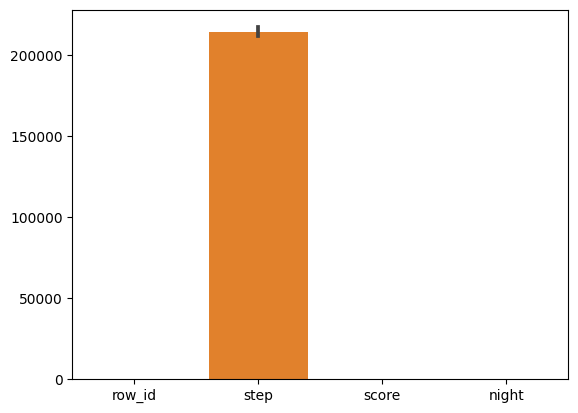

In [11]:
sns.barplot(combined)

<Axes: >

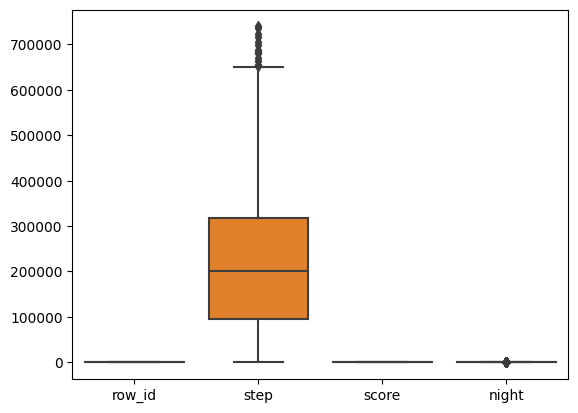

In [12]:
sns.boxplot(combined)

<Axes: >

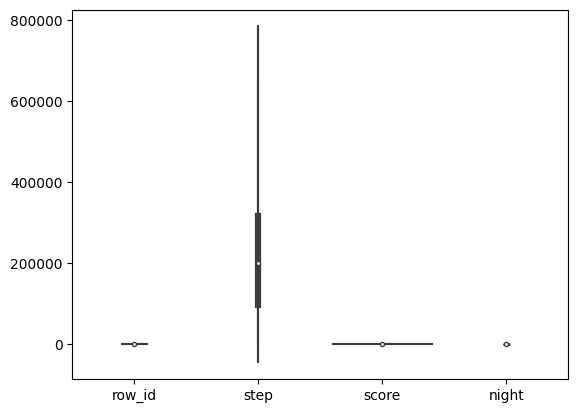

In [13]:
sns.violinplot(combined)

<Axes: ylabel='Density'>

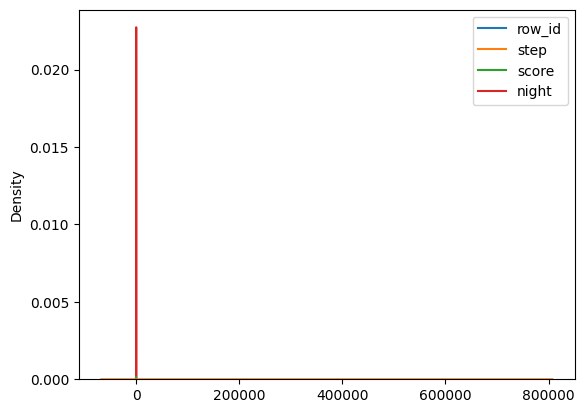

In [14]:
sns.kdeplot(combined)

<Axes: >

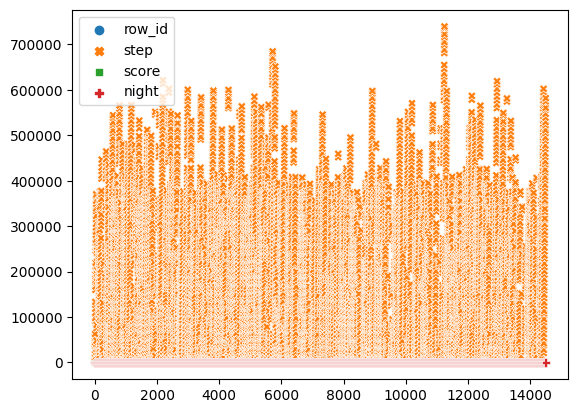

In [15]:
sns.scatterplot(combined)

In [16]:
combined.skew

<bound method NDFrame._add_numeric_operations.<locals>.skew of        row_id     series_id      step   event  score  night  \
0         0.0  038441c925bb     100.0   onset    0.0    NaN   
1         1.0  038441c925bb     105.0  wakeup    0.0    NaN   
2         2.0  03d92c9f6f8a      80.0   onset    0.5    NaN   
3         3.0  03d92c9f6f8a     110.0  wakeup    0.5    NaN   
4         4.0  0402a003dae9      90.0   onset    1.0    NaN   
...       ...           ...       ...     ...    ...    ...   
14503     NaN  fe90110788d2  560604.0  wakeup    NaN   33.0   
14504     NaN  fe90110788d2  574620.0   onset    NaN   34.0   
14505     NaN  fe90110788d2  581604.0  wakeup    NaN   34.0   
14506     NaN  fe90110788d2       NaN   onset    NaN   35.0   
14507     NaN  fe90110788d2       NaN  wakeup    NaN   35.0   

                      timestamp  
0                           NaN  
1                           NaN  
2                           NaN  
3                           NaN  
4         

In [17]:
combined.kurt

<bound method NDFrame._add_numeric_operations.<locals>.kurt of        row_id     series_id      step   event  score  night  \
0         0.0  038441c925bb     100.0   onset    0.0    NaN   
1         1.0  038441c925bb     105.0  wakeup    0.0    NaN   
2         2.0  03d92c9f6f8a      80.0   onset    0.5    NaN   
3         3.0  03d92c9f6f8a     110.0  wakeup    0.5    NaN   
4         4.0  0402a003dae9      90.0   onset    1.0    NaN   
...       ...           ...       ...     ...    ...    ...   
14503     NaN  fe90110788d2  560604.0  wakeup    NaN   33.0   
14504     NaN  fe90110788d2  574620.0   onset    NaN   34.0   
14505     NaN  fe90110788d2  581604.0  wakeup    NaN   34.0   
14506     NaN  fe90110788d2       NaN   onset    NaN   35.0   
14507     NaN  fe90110788d2       NaN  wakeup    NaN   35.0   

                      timestamp  
0                           NaN  
1                           NaN  
2                           NaN  
3                           NaN  
4         

<Axes: >

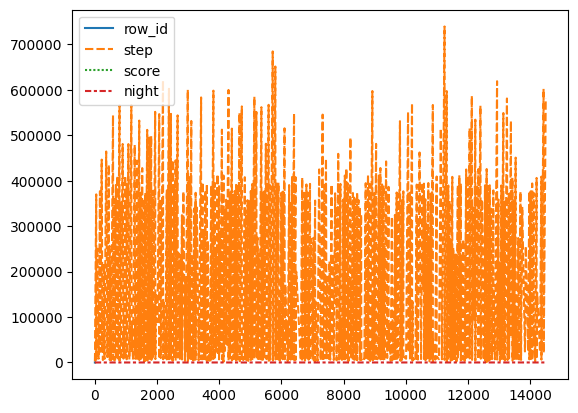

In [18]:
sns.lineplot(combined)

In [20]:
import seaborn as sns

<Axes: ylabel='Count'>

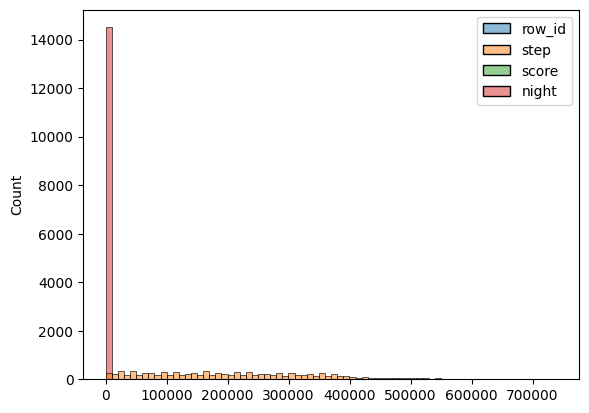

In [19]:
sns.histplot(combined)

In [21]:
cat_cols = combined.select_dtypes(include='object')

In [22]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

series_id
series_id
78569a801a38    168
f564985ab692    124
fb223ed2278c    106
f56824b503a0    100
cfeb11428dd7     94
               ... 
3a9a9dc2cbd9     12
13b4d6a01d27     10
60e51cad2ffb     10
10469f6765bf      8
349c5562ee2c      4
Name: count, Length: 277, dtype: int64
__________________________________________________
event
event
onset     7257
wakeup    7257
Name: count, dtype: int64
__________________________________________________
timestamp
timestamp
2017-11-27T21:37:00-0500    3
2019-01-29T06:52:00-0500    3
2017-11-28T06:52:00-0500    3
2018-11-23T07:00:00-0500    3
2017-09-05T07:22:00-0400    2
                           ..
2018-03-09T21:06:00-0500    1
2018-03-09T07:15:00-0500    1
2018-03-08T21:07:00-0500    1
2018-03-07T21:00:00-0500    1
2017-09-07T09:17:00-0400    1
Name: count, Length: 9360, dtype: int64
__________________________________________________


In [23]:
num_cols = combined.select_dtypes(include='number')

In [24]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

row_id
row_id
0.0    1
1.0    1
2.0    1
3.0    1
4.0    1
5.0    1
Name: count, dtype: int64
__________________________________________________
step
step
83016.0     6
151200.0    6
38064.0     5
131892.0    5
194760.0    5
           ..
11604.0     1
5388.0      1
326544.0    1
319308.0    1
581604.0    1
Name: count, Length: 7505, dtype: int64
__________________________________________________
score
score
0.0    2
0.5    2
1.0    2
Name: count, dtype: int64
__________________________________________________
night
night
2.0     554
3.0     552
4.0     552
5.0     550
6.0     546
       ... 
67.0      2
66.0      2
65.0      2
63.0      2
84.0      2
Name: count, Length: 84, dtype: int64
__________________________________________________


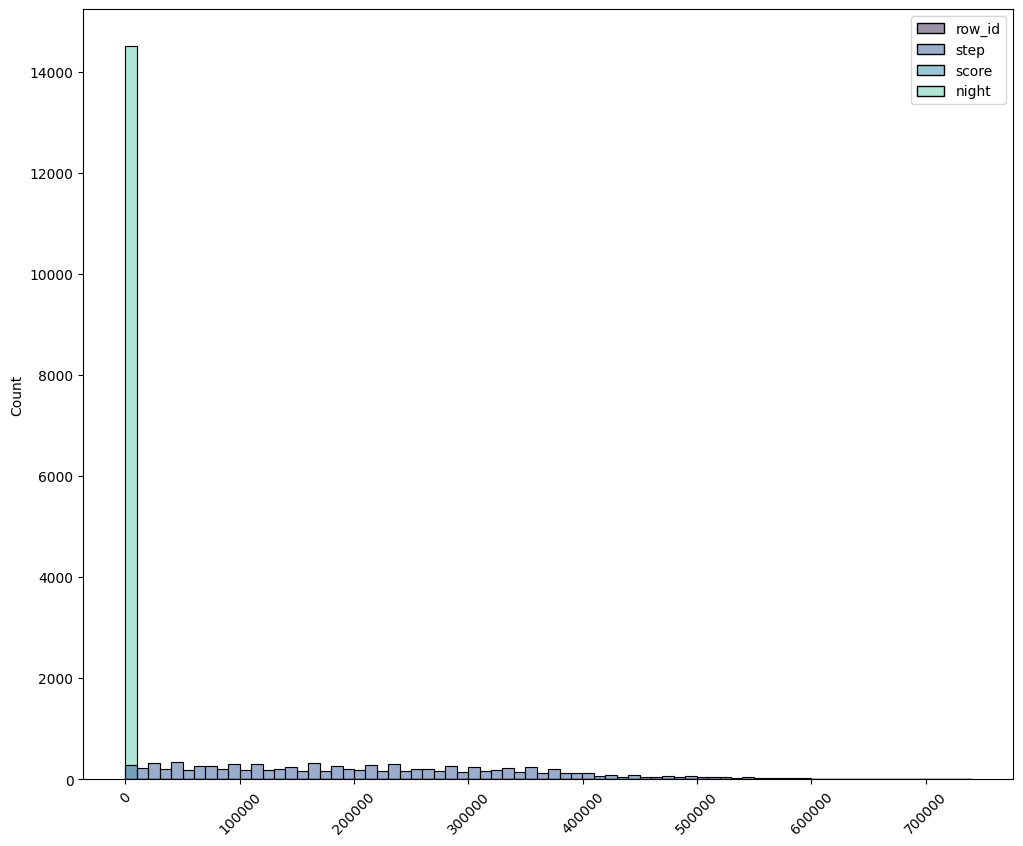

In [25]:
plt.figure(figsize=(12,10))
sns.histplot(data=combined,palette='mako');
plt.xticks(rotation=45);

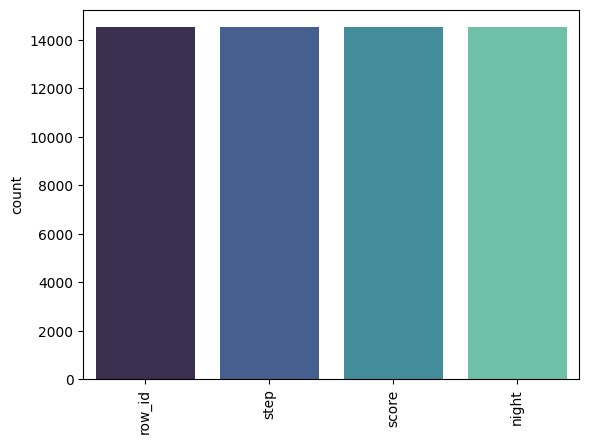

In [26]:
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=90);

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


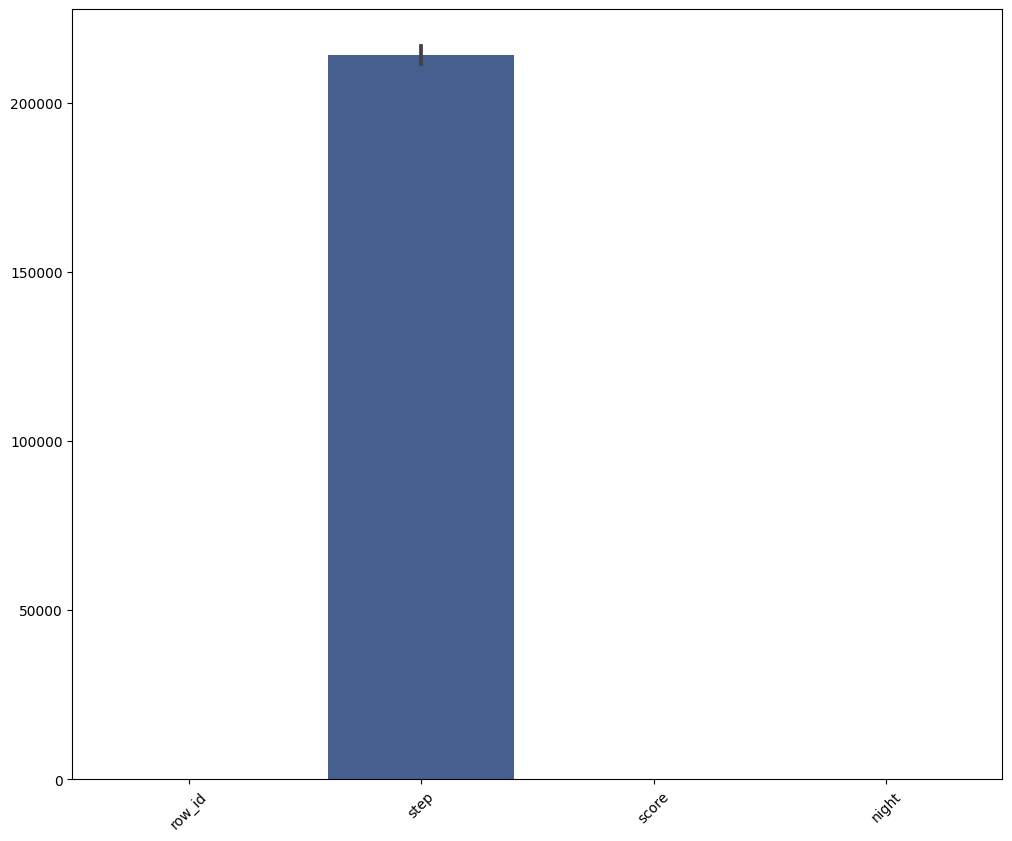

In [27]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=45);

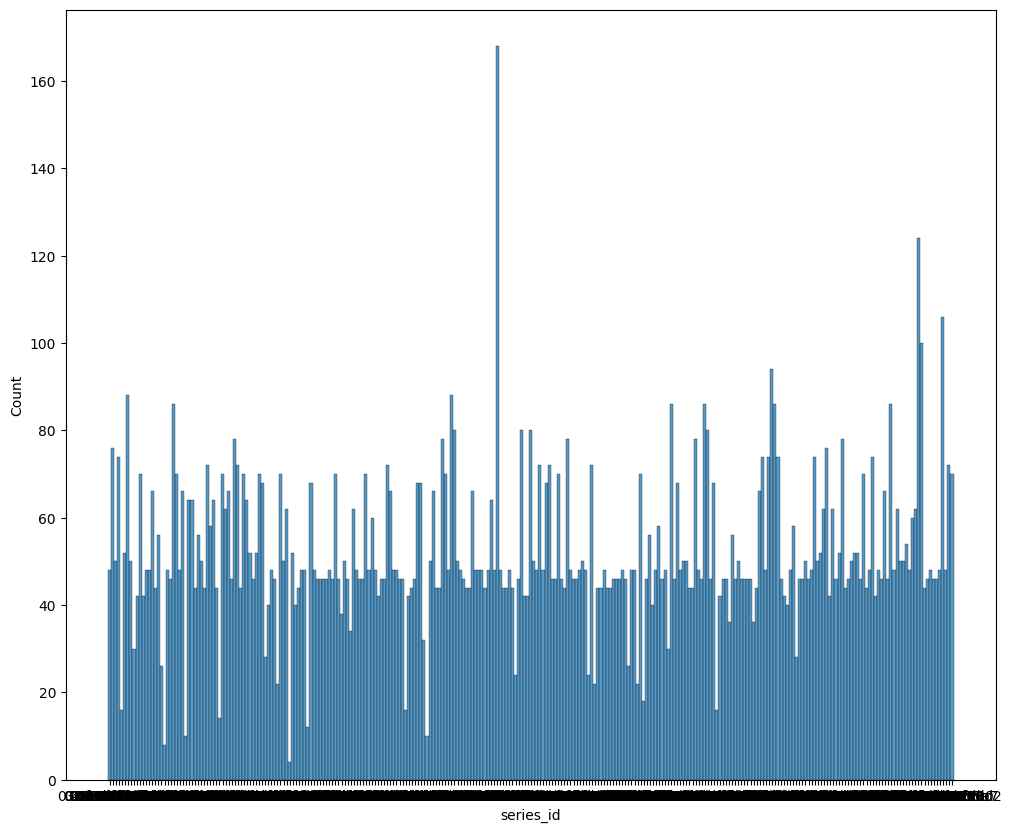

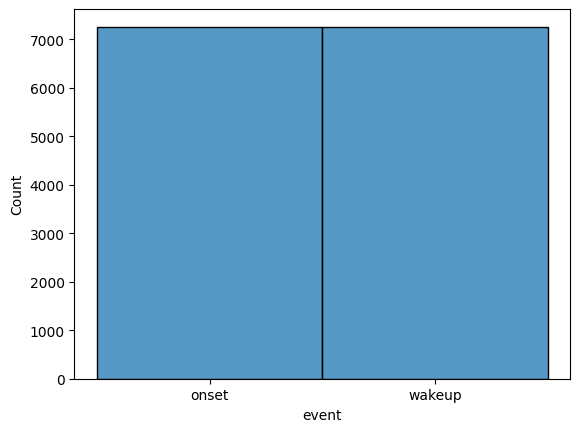

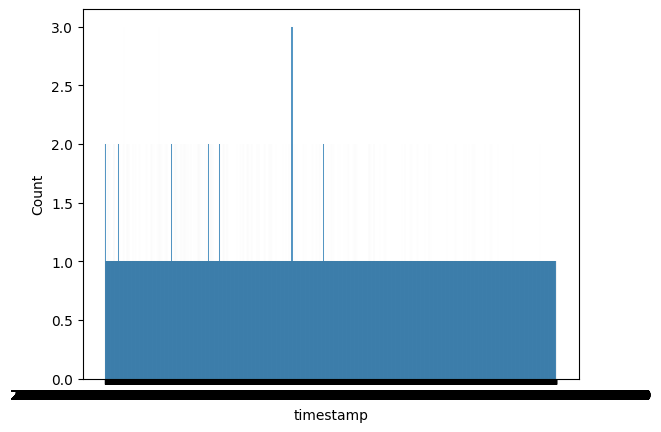

In [28]:
plt.figure(figsize=(12,10))
x=1
for i in cat_cols:
    sns.histplot(data=combined,x=i)
    print('\n')
    plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


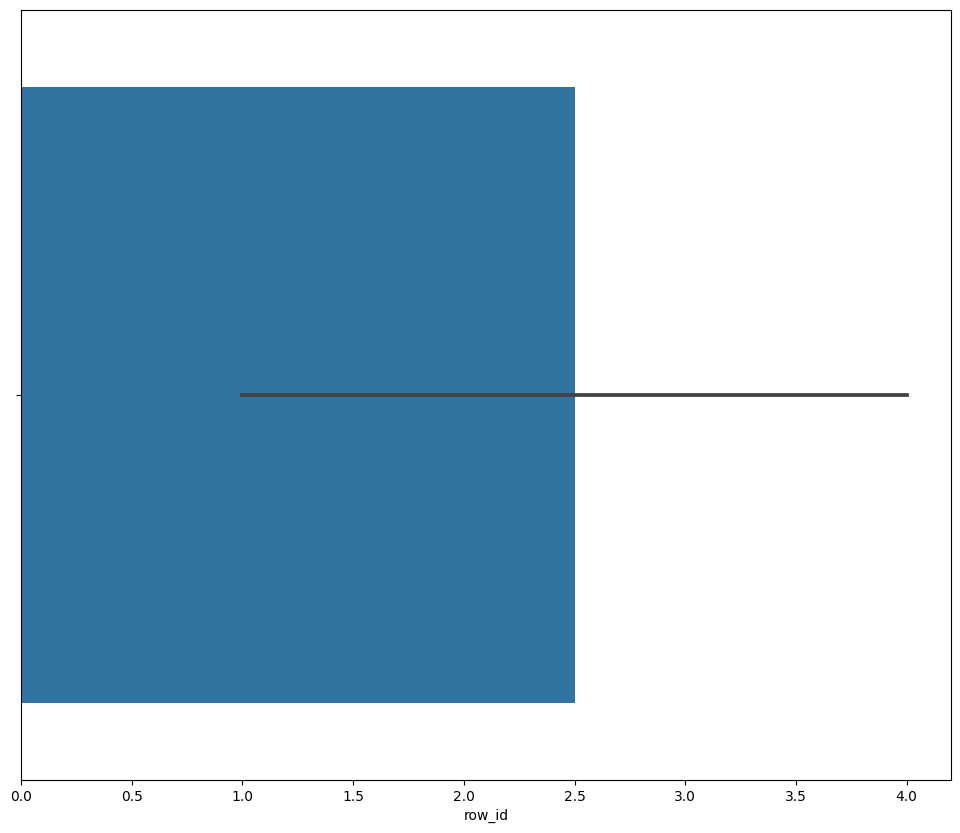

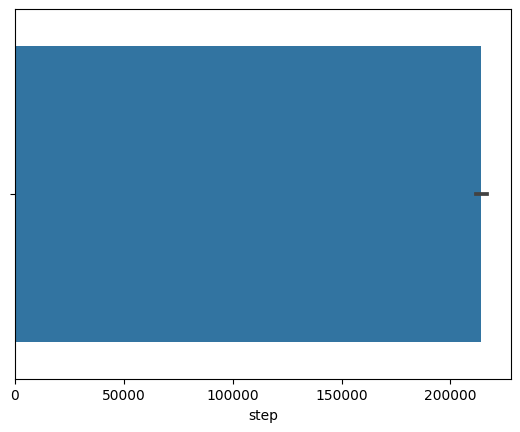

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


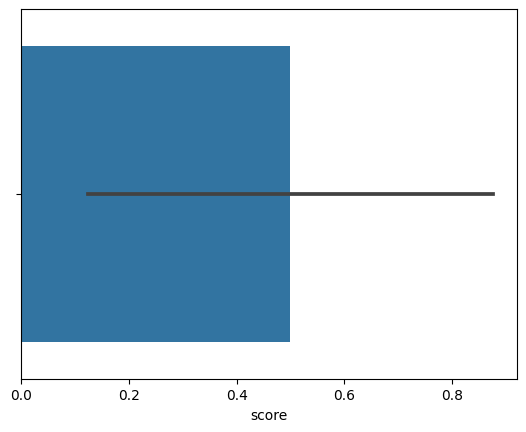

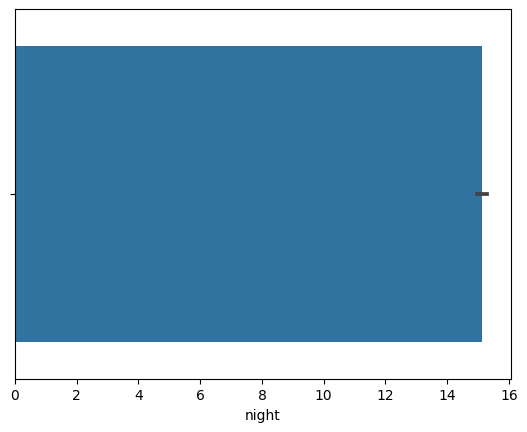

In [29]:
plt.figure(figsize=(12,10))
x=1
for i in num_cols:
    sns.barplot(data=combined,x=i)
    print('\n')
    plt.show() 

<Axes: >

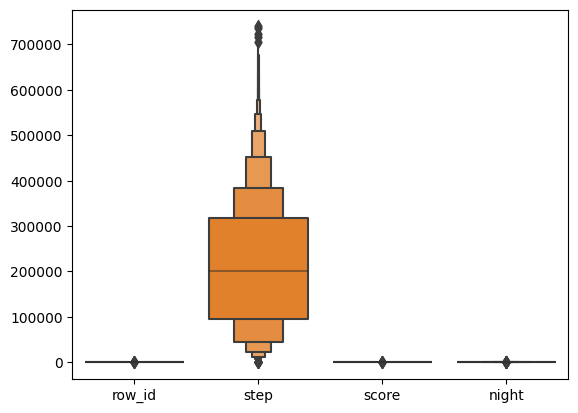

In [30]:
sns.boxenplot(combined) 

In [32]:
combined.head ()

,row_id,series_id,step,event,score,night,timestamp
0,0.0,038441c925bb,100.0,onset,0.0,NaN,NaN
1,1.0,038441c925bb,105.0,wakeup,0.0,NaN,NaN
2,2.0,03d92c9f6f8a,80.0,onset,0.5,NaN,NaN
3,3.0,03d92c9f6f8a,110.0,wakeup,0.5,NaN,NaN
4,4.0,0402a003dae9,90.0,onset,1.0,NaN,NaN


In [35]:
x = combined [['series_id']]

In [36]:
y = combined[['series_id']]

In [38]:
from sklearn.model_selection import train_test_split

In [42]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
lr = LinearRegression()

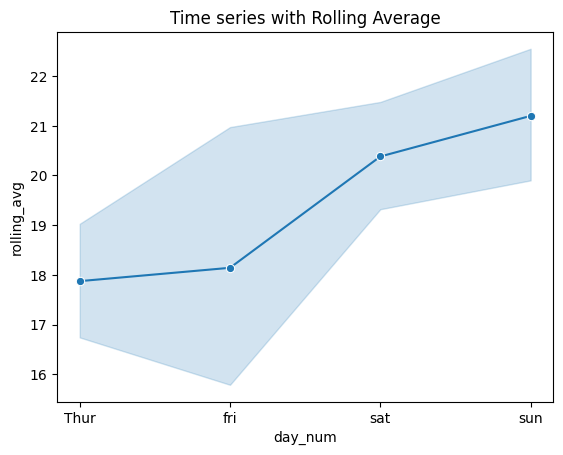

In [46]:
df_tips = sns.load_dataset("tips")
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg']=df_tips['total_bill'].rolling(window=3).mean()

sns.lineplot(x='day_num', y='rolling_avg', data=df_tips,marker='o')
plt.xticks(ticks=[0,1,2,3],labels=['Thur','fri','sat','sun'])
plt.title("Time series with Rolling Average")
plt.show()